In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [101]:
data=pd.read_csv("fake_job_postings.csv")

In [3]:
data.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [102]:
df=data.drop(['company_profile','description','requirements','benefits','job_id'],axis=1)	

In [8]:
df.shape

(17880, 13)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   title                17880 non-null  object
 1   location             17534 non-null  object
 2   department           6333 non-null   object
 3   salary_range         2868 non-null   object
 4   telecommuting        17880 non-null  int64 
 5   has_company_logo     17880 non-null  int64 
 6   has_questions        17880 non-null  int64 
 7   employment_type      14409 non-null  object
 8   required_experience  10830 non-null  object
 9   required_education   9775 non-null   object
 10  industry             12977 non-null  object
 11  function             11425 non-null  object
 12  fraudulent           17880 non-null  int64 
dtypes: int64(4), object(9)
memory usage: 1.8+ MB


In [10]:
df.head()

,title,location,department,salary_range,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,Marketing Intern,"US, NY, New York",Marketing,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [11]:
df.describe()


,telecommuting,has_company_logo,has_questions,fraudulent
count,17880.000000,17880.000000,17880.000000,17880.000000
mean,0.042897,0.795302,0.491723,0.048434
std,0.202631,0.403492,0.499945,0.214688
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,0.000000
50%,0.000000,1.000000,0.000000,0.000000
75%,0.000000,1.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000


In [103]:
df.drop_duplicates(inplace=True)

In [15]:
df.shape

(17199, 13)

In [21]:
df['title'].value_counts()

title
English Teacher Abroad                                308
Graduates: English Teacher Abroad (Conversational)    144
Customer Service Associate                            119
English Teacher Abroad                                 94
English Teacher Abroad (Conversational)                83
                                                     ... 
Sr. Scm Web Development Technical Lead                  1
Junior Game Designer                                    1
SEO CONTENT WRITER                                      1
Communication Designer                                  1
Payroll Clerk                                           1
Name: count, Length: 11231, dtype: int64

In [22]:
df['location'].value_counts()

location
GB, LND, London                    710
US, NY, New York                   614
US, CA, San Francisco              459
GR, I, Athens                      456
US, ,                              338
                                  ... 
US, MN,    Minneapolis               1
US, TX, wichita falls                1
US, MD, 20855                        1
US, OR, NW Portland & Hillsboro      1
US, NY, Manhattan                    1
Name: count, Length: 3105, dtype: int64

In [23]:
df['department'].value_counts()

department
Sales               539
Engineering         470
Marketing           397
Operations          262
IT                  221
                   ... 
HOTEL JOBS            1
TD                    1
Parts                 1
LOgistics             1
Sales Operations      1
Name: count, Length: 1337, dtype: int64

In [25]:
df['salary_range'].value_counts()

salary_range
0-0            139
40000-50000     66
30000-40000     52
45000-67000     36
25000-30000     36
              ... 
1234-12345       1
1517-1517        1
Dec-25           1
26000-50000      1
4500-5000        1
Name: count, Length: 874, dtype: int64

In [26]:

df['telecommuting'].value_counts()

telecommuting
0    16456
1      743
Name: count, dtype: int64

In [27]:
df['has_company_logo'].value_counts()

has_company_logo
1    13679
0     3520
Name: count, dtype: int64

In [28]:
df['has_questions'].value_counts()

has_questions
0    8697
1    8502
Name: count, dtype: int64

In [29]:
df['employment_type'].value_counts()

employment_type
Full-time    11129
Contract      1502
Part-time      747
Temporary      228
Other          225
Name: count, dtype: int64

In [31]:
df['required_experience'].value_counts()

required_experience
Mid-Senior level    3687
Entry level         2549
Associate           2215
Not Applicable      1054
Director             375
Internship           368
Executive            140
Name: count, dtype: int64

In [32]:
df['required_education'].value_counts()

required_education
Bachelor's Degree                    5019
High School or equivalent            1915
Unspecified                          1320
Master's Degree                       407
Associate Degree                      262
Certification                         158
Some College Coursework Completed      99
Professional                           73
Vocational                             47
Some High School Coursework            27
Doctorate                              25
Vocational - HS Diploma                 9
Vocational - Degree                     6
Name: count, dtype: int64

In [33]:
df['industry'].value_counts()

industry
Information Technology and Services    1695
Computer Software                      1326
Internet                               1047
Education Management                    813
Marketing and Advertising               798
                                       ... 
Sporting Goods                            1
Museums and Institutions                  1
Shipbuilding                              1
Alternative Dispute Resolution            1
Ranching                                  1
Name: count, Length: 131, dtype: int64

In [34]:
df['function'].value_counts()

function
Information Technology    1706
Sales                     1424
Engineering               1316
Customer Service          1108
Marketing                  812
Administrative             604
Design                     334
Education                  322
Health Care Provider       316
Other                      312
Management                 288
Business Development       226
Accounting/Auditing        207
Human Resources            199
Project Management         180
Finance                    165
Art/Creative               131
Consulting                 130
Writing/Editing            129
Product Management         113
Production                 113
Quality Assurance          108
Advertising                 86
Business Analyst            83
Data Analyst                82
Public Relations            76
Manufacturing               69
General Business            66
Research                    49
Strategy/Planning           46
Legal                       40
Training                    37

In [35]:
df.isnull().sum()

title                      0
location                 340
department             11011
salary_range           14404
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3368
required_experience     6811
required_education      7832
industry                4728
function                6205
fraudulent                 0
dtype: int64

In [104]:
df = df.drop(['department','salary_range'], axis=1)


In [105]:
cols_to_fill = ['location','employment_type','required_experience',
                'required_education','industry','function']

for col in cols_to_fill:
    df[col] = df[col].fillna(df[col].mode()[0])


In [38]:
df

,title,location,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,Marketing Intern,"US, NY, New York",0,1,0,Other,Internship,Bachelor's Degree,Information Technology and Services,Marketing,0
1,Customer Service - Cloud Video Production,"NZ, , Auckland",0,1,0,Full-time,Not Applicable,Bachelor's Degree,Marketing and Advertising,Customer Service,0
2,Commissioning Machinery Assistant (CMA),"US, IA, Wever",0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Information Technology and Services,Information Technology,0
3,Account Executive - Washington DC,"US, DC, Washington",0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,Bill Review Manager,"US, FL, Fort Worth",0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0
...,...,...,...,...,...,...,...,...,...,...,...
17875,Account Director - Distribution,"CA, ON, Toronto",0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
17876,Payroll Accountant,"US, PA, Philadelphia",0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Internet,Accounting/Auditing,0
17877,Project Cost Control Staff Engineer - Cost Con...,"US, TX, Houston",0,0,0,Full-time,Mid-Senior level,Bachelor's Degree,Information Technology and Services,Information Technology,0
17878,Graphic Designer,"NG, LA, Lagos",0,0,1,Contract,Not Applicable,Professional,Graphic Design,Design,0


In [119]:
categorical_cols = [
    'telecommuting',
    'has_company_logo',
    'has_questions',
    'employment_type',
    'required_experience',
    'required_education',
    'industry',
    'function',
    'location',
   
]

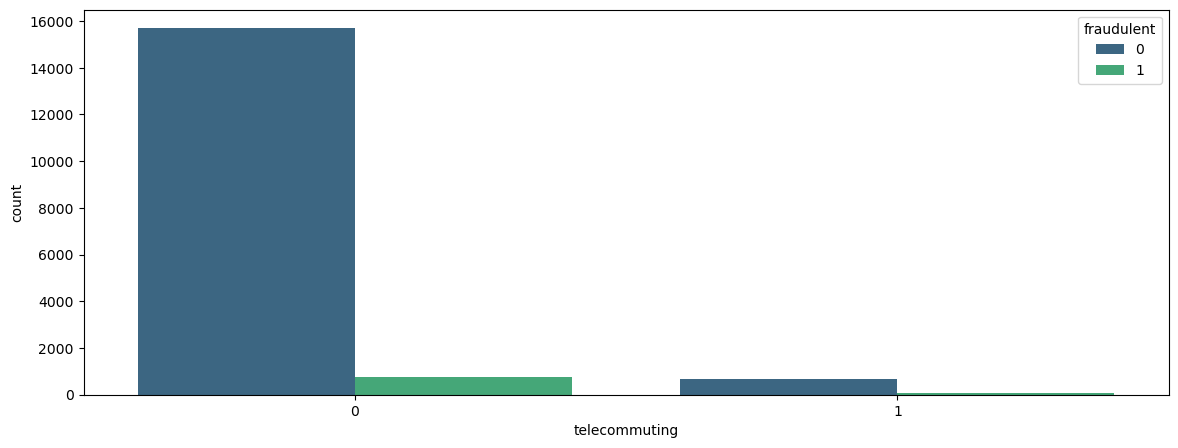

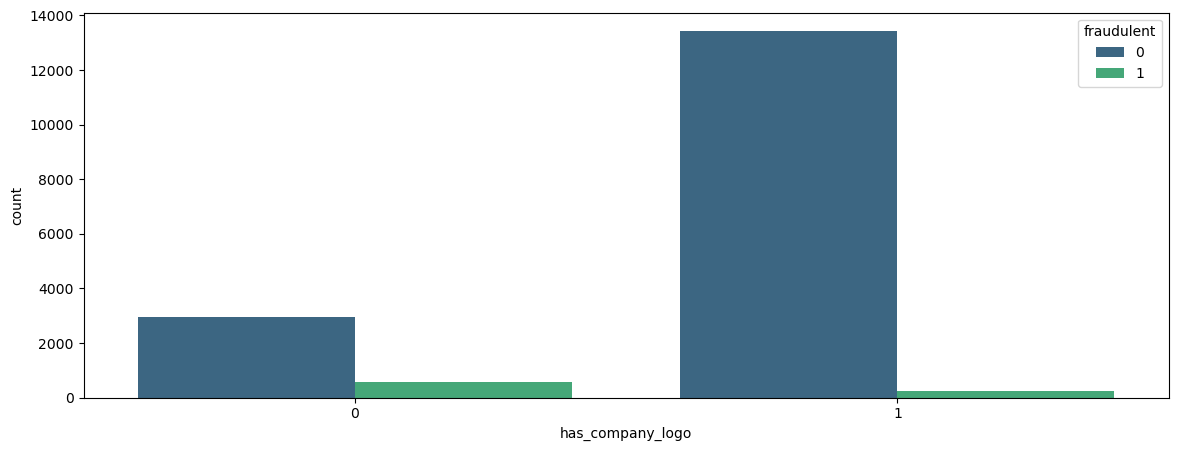

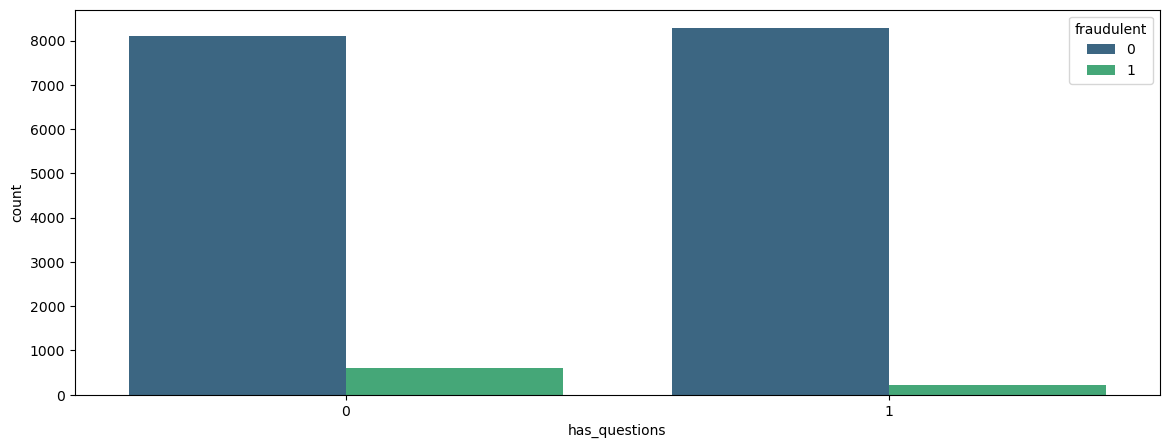

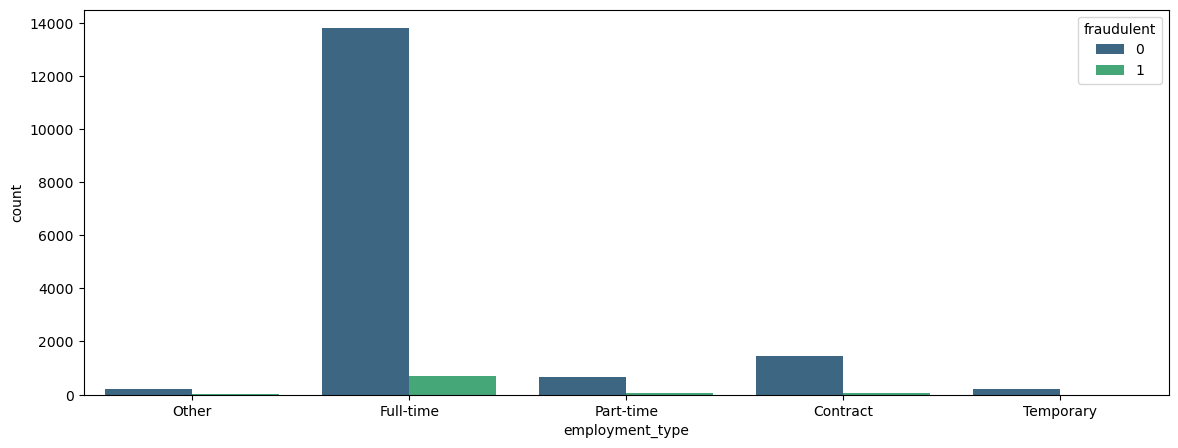

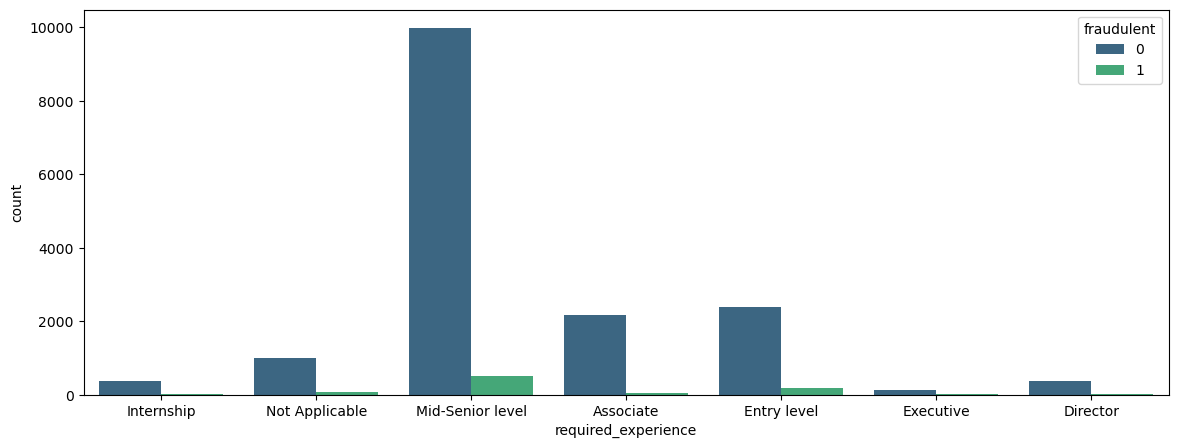

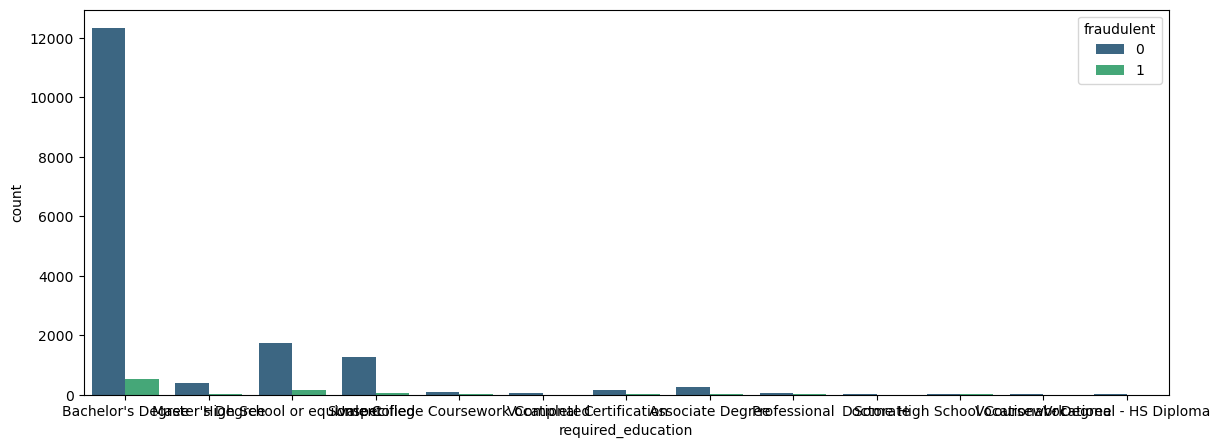

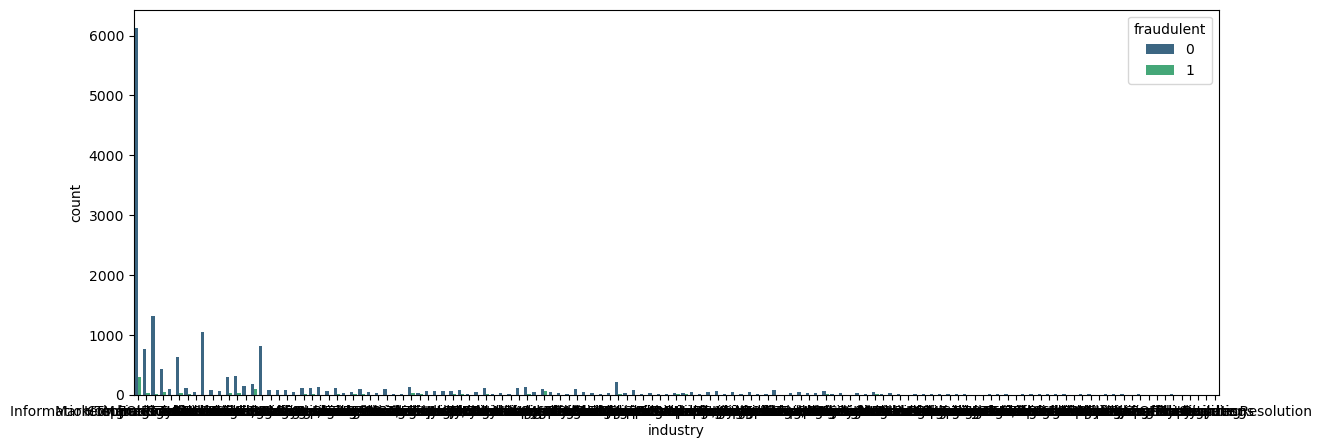

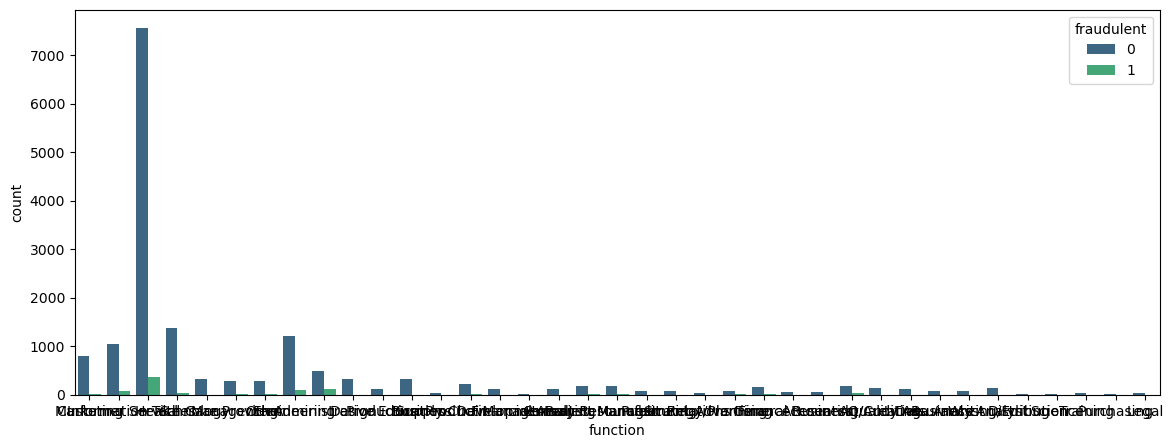

C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\ProgramData\ana

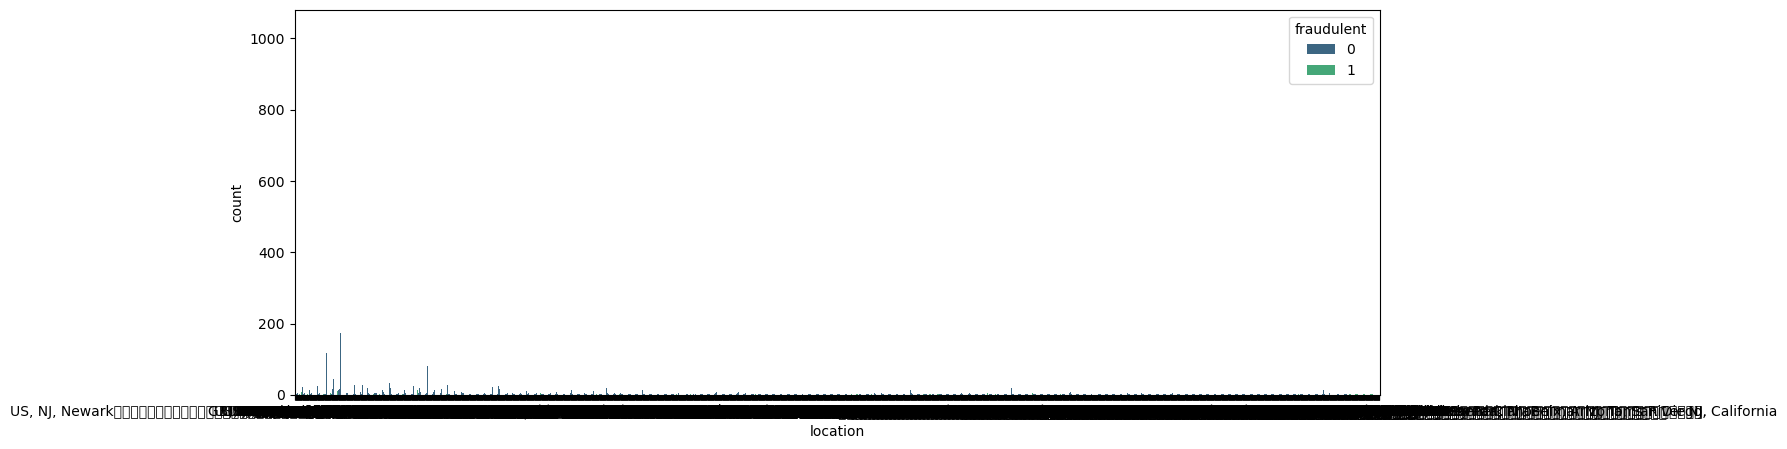

In [120]:

for col in categorical_cols:
    plt.figure(figsize=(14,5))
    ax = sns.countplot(data=df, x=col, hue='fraudulent', palette="viridis")
    plt.show()

"""Dataset is highly imbalanced:
Real job posts are far more than fraudulent ones → important for modelling.

Telecommuting feature is weak:
Most jobs (real + fake) are non-telecommuting → limited separation power.

Company logo feature is very strong:
Real jobs almost always have a company logo, fake ones mostly don’t.

Screening questions matter:
Jobs without applicant questions show higher fraud frequency.

Full-time jobs dominate dataset:
Majority postings are full-time → scammers target popular job type.

Fraud mostly appears in mid-senior level:
Fake roles often pretend to be senior/high-skill positions to look legit.

Intern-level & executive roles show very low fraud:
Fraudsters avoid small audience categories.

Categorical variety is good:
Industry, function, experience, education fields give the model a structure to learn.

Dataset patterns are logical:
Behaviour matches real-world scam strategy → easier to model.

Feature relationships look helpful:
Combining logo + experience + employment_type will support prediction.

No unusual noise found:
Dataset quality good, EDA shows stable structure.

Accuracy expectation realistic:
With structured data: ~75–85%
With text later: ~90%+"""

In [121]:
plt.figure(figsize=(14,8))
sns.heatmap(df[categorical_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

ValueError: could not convert string to float: 'Other'

<Figure size 1400x800 with 0 Axes>

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17199 entries, 0 to 17879
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   title                17199 non-null  object
 1   location             17199 non-null  int64 
 2   telecommuting        17199 non-null  int64 
 3   has_company_logo     17199 non-null  int64 
 4   has_questions        17199 non-null  int64 
 5   employment_type      17199 non-null  int64 
 6   required_experience  17199 non-null  int64 
 7   required_education   17199 non-null  int64 
 8   industry             17199 non-null  int64 
 9   function             17199 non-null  int64 
 10  fraudulent           17199 non-null  int64 
dtypes: int64(10), object(1)
memory usage: 1.6+ MB


In [71]:
df['title']

0                                         Marketing Intern
1                Customer Service - Cloud Video Production
2                  Commissioning Machinery Assistant (CMA)
3                        Account Executive - Washington DC
4                                      Bill Review Manager
                               ...                        
17875                     Account Director - Distribution 
17876                                   Payroll Accountant
17877    Project Cost Control Staff Engineer - Cost Con...
17878                                     Graphic Designer
17879                           Web Application Developers
Name: title, Length: 17199, dtype: object

In [106]:
df.drop('title', axis=1, inplace=True)


In [73]:
df.head()

,location,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,2535,0,1,0,2,4,1,58,22,0
1,1073,0,1,0,1,6,1,75,7,0
2,1867,0,1,0,1,5,1,58,18,0
3,1703,0,1,0,1,5,1,22,31,0
4,1741,0,1,1,1,5,1,51,16,0


In [ ]:
from sklearn.model_selection import train_test_split
X = df.drop('fraudulent', axis=1)
y = df['fraudulent']


In [123]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)
from sklearn.preprocessing import OrdinalEncoder


enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

X_train[categorical_cols] = enc.fit_transform(X_train[categorical_cols])
X_test[categorical_cols] = enc.transform(X_test[categorical_cols])


In [124]:
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier)
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

In [132]:
models = {
    'RandomForest': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
    'XGBoost': XGBClassifier(tree_method='hist', random_state=42, eval_metric='logloss'),
    'GradientBoosting': GradientBoostingClassifier(),
    
    'DecisionTree': DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'LogisticRegression': LogisticRegression(max_iter=2000),
}


In [137]:
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix, f1_score
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_preds = model.predict(X_test)
    acc = accuracy_score(y_test, y_preds)
    probs = model.predict_proba(X_test)[:,1]   
    y_pred_thresh = (probs > 0.2).astype(int)
    f1 = f1_score(y_test, y_pred_thresh)
    
    

    results[name] = (acc, f1)
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    print(name, "CV Mean =", scores.mean())
    



results


RandomForest CV Mean = 0.9646786499758978
XGBoost CV Mean = 0.9723162960954447
GradientBoosting CV Mean = 0.9626833273077849
DecisionTree CV Mean = 0.949144974692697
LogisticRegression CV Mean = 0.9524428702699446


{'RandomForest': (0.9635306553911205, 0.5538922155688623),
 'XGBoost': (0.974277660324172, 0.6103286384976526),
 'GradientBoosting': (0.9645877378435518, 0.5131375579598145),
 'DecisionTree': (0.9499647639182522, 0.5084175084175084),
 'LogisticRegression': (0.9552501761804087, 0.3076923076923077)}

In [128]:
df['fraudulent'].value_counts(normalize=True)




fraudulent
0    0.952265
1    0.047735
Name: proportion, dtype: float64

In [129]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_preds)
cm


array([[5412,    0],
       [ 254,   10]])

In [138]:
"""Initially accuracy was 97%, but fraud recall was extremely low
After threshold tuning, XGBoost achieved F1-score = 0.61, capturinga significantly larger proportion of
fraudulent samples. Accuracy
 dropped slightly, which is acceptable since fraud recall is the primary
                business objective."""


'Initially accuracy was 97%, but fraud recall was extremely low\nAfter threshold tuning, XGBoost achieved F1-score = 0.61, capturinga significantly larger proportion of\nfraudulent samples. Accuracy\n dropped slightly, which is acceptable since fraud recall is the primary\n                business objective.'

In [139]:
import joblib
joblib.dump(models["XGBoost"], "xgb_model.pkl")


['xgb_model.pkl']

In [140]:
df.to_csv("cleaned_dataset.csv", index=False)
